In [5]:
import warnings
warnings.filterwarnings("ignore")

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

import math

import optuna
import mlflow

In [6]:
# ---------------------------
# Config gerais
# ---------------------------
TARGET = 'boi_real'
FREQ = 'B'              # business day
VALID_DAYS = 180        # ~6 meses corridos (ajuste à sua janela)
METRIC = 'RMSE'         # ou 'MAPE'
HORIZONS = [30, 60, 90] # dias corridos
H_MAX = max(HORIZONS)


In [3]:
def split_time(y: pd.Series, test_days: int = 180, exog: pd.DataFrame = None):
    """
    Divide uma série temporal e suas variáveis exógenas em treino e teste.

    Parâmetros:
    - y: Série temporal com índice datetime.
    - test_days: Número de dias para o conjunto de teste.
    - exog: DataFrame com variáveis exógenas, alinhado com y.

    Retorna:
    - y_train, y_test: Série de treino e teste.
    - X_train, X_test: Exógenas de treino e teste (ou None).
    - split_date: Data de início do teste.
    """
    if not isinstance(y.index, pd.DatetimeIndex):
        raise TypeError("A série y deve ter índice datetime.")

    y = y.sort_index()
    if exog is not None:
        exog = exog.sort_index().reindex(y.index)

    split_date = y.index.max() - pd.Timedelta(days=test_days - 1)
    
    y_train = y[y.index < split_date]
    y_test = y[y.index >= split_date]

    if exog is not None:
        X_train = exog.loc[y_train.index]
        X_test = exog.loc[y_test.index]
    else:
        X_train = X_test = None

    return y_train, y_test, X_train, X_test

In [7]:
tscv = TimeSeriesSplit(test_size=VALID_DAYS)

### Dados Não-Normalizados

In [6]:
df_agro = pd.read_csv('df_selected.csv')
df_agro = df_agro.drop('Unnamed: 0', axis=1)
df_agro.head()

,data,boi_real,boi_dolar,CovidPeriodFlag,TEMPERATURA,ipca,selic,PIB,cme_valor,soja_real,soja_dolar,soja_futuro,milho_futuro,milho_real,milho_dolar,taxa,el_nino_encoded
0,2020-01-02,192.95,47.96,0,28.33,4.19,4.4,0.41,201.85,88.08,21.89,956.25,391.50,48.43,12.04,4.0260,0
1,2020-01-03,196.70,48.53,0,26.00,4.19,4.4,0.41,204.55,88.91,21.94,941.50,386.50,48.91,12.07,4.0669,0
2,2020-01-04,196.70,48.53,0,25.95,4.19,4.4,0.41,204.55,88.91,21.94,941.50,386.50,48.91,12.07,4.0669,0
3,2020-01-05,196.70,48.53,0,28.10,4.19,4.4,0.41,204.55,88.91,21.94,941.50,386.50,48.91,12.07,4.0669,0
4,2020-01-06,196.40,48.24,0,27.04,4.19,4.4,0.41,205.39,88.24,21.68,944.75,384.75,48.99,12.03,4.0616,0


In [7]:
X = df_agro.drop(columns=['data','boi_dolar','boi_real'])
X.index = pd.to_datetime(df_agro['data'])
X.head()

,CovidPeriodFlag,TEMPERATURA,ipca,selic,PIB,cme_valor,soja_real,soja_dolar,soja_futuro,milho_futuro,milho_real,milho_dolar,taxa,el_nino_encoded
data,,,,,,,,,,,,,,
2020-01-02,0,28.33,4.19,4.4,0.41,201.85,88.08,21.89,956.25,391.50,48.43,12.04,4.0260,0
2020-01-03,0,26.00,4.19,4.4,0.41,204.55,88.91,21.94,941.50,386.50,48.91,12.07,4.0669,0
2020-01-04,0,25.95,4.19,4.4,0.41,204.55,88.91,21.94,941.50,386.50,48.91,12.07,4.0669,0
2020-01-05,0,28.10,4.19,4.4,0.41,204.55,88.91,21.94,941.50,386.50,48.91,12.07,4.0669,0
2020-01-06,0,27.04,4.19,4.4,0.41,205.39,88.24,21.68,944.75,384.75,48.99,12.03,4.0616,0


In [8]:
y = pd.DataFrame()
y['boi_real'] = df_agro['boi_real']
y.index = pd.to_datetime(df_agro['data'])
y.head()

,boi_real
data,
2020-01-02,192.95
2020-01-03,196.70
2020-01-04,196.70
2020-01-05,196.70
2020-01-06,196.40


In [9]:
y_ts_train, y_ts_test, X_ts_train, X_ts_test = split_time(y, test_days=H_MAX, exog=X)

In [10]:
X_ts_train.head()

,CovidPeriodFlag,TEMPERATURA,ipca,selic,PIB,cme_valor,soja_real,soja_dolar,soja_futuro,milho_futuro,milho_real,milho_dolar,taxa,el_nino_encoded
data,,,,,,,,,,,,,,
2020-01-02,0,28.33,4.19,4.4,0.41,201.85,88.08,21.89,956.25,391.50,48.43,12.04,4.0260,0
2020-01-03,0,26.00,4.19,4.4,0.41,204.55,88.91,21.94,941.50,386.50,48.91,12.07,4.0669,0
2020-01-04,0,25.95,4.19,4.4,0.41,204.55,88.91,21.94,941.50,386.50,48.91,12.07,4.0669,0
2020-01-05,0,28.10,4.19,4.4,0.41,204.55,88.91,21.94,941.50,386.50,48.91,12.07,4.0669,0
2020-01-06,0,27.04,4.19,4.4,0.41,205.39,88.24,21.68,944.75,384.75,48.99,12.03,4.0616,0


In [11]:
print(X_ts_train.shape)
print(y_ts_train.shape)
print(X_ts_test.shape)
print(y_ts_test.shape)

(1570, 14)
(1570, 1)
(90, 14)
(90, 1)


### Dados Normalizados

In [10]:
df_norm_feat_selected = pd.read_csv('df_norm_selected.csv')
df_norm_feat_selected = df_norm_feat_selected.drop('Unnamed: 0', axis=1)
df_norm_feat_selected.head()

,data,boi_real,boi_dolar,CovidPeriodFlag,PIB_Agro,taxa
0,2020-01-02,192.95,47.96,0,0.278479,0.000000
1,2020-01-03,196.70,48.53,0,0.278479,0.011745
2,2020-01-04,196.70,48.53,0,0.278479,0.011745
3,2020-01-05,196.70,48.53,0,0.278479,0.011745
4,2020-01-06,196.40,48.24,0,0.278479,0.010212


In [78]:
X = df_norm_feat_selected.drop(columns='boi_real')
X.set_index('data', inplace=True) 
X.head()

,boi_dolar,CovidPeriodFlag,PIB_Agro,taxa
data,,,,
2020-01-02,47.96,0,0.278479,0.000000
2020-01-03,48.53,0,0.278479,0.011745
2020-01-04,48.53,0,0.278479,0.011745
2020-01-05,48.53,0,0.278479,0.011745
2020-01-06,48.24,0,0.278479,0.010212


In [79]:
y = df_norm_feat_selected['boi_real']
y.index = pd.to_datetime(df_norm_feat_selected['data'])
y.head()

data
2020-01-02    192.95
2020-01-03    196.70
2020-01-04    196.70
2020-01-05    196.70
2020-01-06    196.40
Name: boi_real, dtype: float64

In [13]:
X_norm = df_norm_feat_selected.drop(columns=['data','boi_real', 'boi_dolar'])
X_norm.index = pd.to_datetime(df_norm_feat_selected['data'])
X_norm.head()

,CovidPeriodFlag,PIB_Agro,taxa
data,,,
2020-01-02,0,0.278479,0.000000
2020-01-03,0,0.278479,0.011745
2020-01-04,0,0.278479,0.011745
2020-01-05,0,0.278479,0.011745
2020-01-06,0,0.278479,0.010212


In [14]:
y_norm = df_norm_feat_selected['boi_real']
y_norm.index = pd.to_datetime(df_norm_feat_selected['data'])
y_norm.head()

data
2020-01-02    192.95
2020-01-03    196.70
2020-01-04    196.70
2020-01-05    196.70
2020-01-06    196.40
Name: boi_real, dtype: float64

In [15]:
y_n_train, y_n_test, X_n_train, X_n_test = split_time(y_norm, test_days=H_MAX, exog=X_norm)

In [16]:
print(X_n_train.shape)
print(y_n_train.shape)
print(X_n_test.shape)
print(y_n_test.shape)

(1570, 3)
(1570,)
(90, 3)
(90,)


## Criando modelos

### 1.Séries Temporais

#### 1.1. ARIMA/SARIMA

Primeiro temos que retirar a colinearidade entre as variáveis dos dados.

### Separando as variáveis em exógenas e alvo para os dados COM os lags e shifts

Agora com as variáveis não colineares podemos aplicar SARIMA.

- Pipeline aplicado

In [2]:

# ============================================
# Pipeline SARIMAX + Optuna + MLflow + Transformers (Yeo-Johnson + MinMax)
# Freq 'D' (diária) e horizontes 30/60/90
# ============================================
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error

import optuna
import mlflow

## Inicializando o Servidor MLflow

Abra um prompt de comando ou terminal, navegue até a pasta do projeto e digite o comando abaixo:

mlflow server --host 127.0.0.1 --port 8282

In [3]:
# ---------------------------
# Config MLflow
# ---------------------------
EXPERIMENT_NAME = "BoiGordo-SARIMAX-D"
TRACKING_URI = "http://127.0.0.1:8282"
mlflow.set_tracking_uri(TRACKING_URI)

In [4]:
# Função para criar o experimento
def cria_experimento(experiment_name):

    # Verifica se o experimento já existe pelo nome
    if experiment := mlflow.get_experiment_by_name(experiment_name):
        # Se o experimento existir, retorna seu ID
        return experiment.experiment_id
    else:
        # Se o experimento não existir, cria um novo e retorna seu ID
        return mlflow.create_experiment(experiment_name)

In [5]:
# Cria o experimento
id_experimento_p1 = cria_experimento(EXPERIMENT_NAME)

In [6]:
id_experimento_p1

'911993001682324505'

### Configuração para exógenas sem lags e shifits

In [7]:
# Função de callback
def callback(study, frozen_trial):

    # Obtém o valor atual do "winner" (vencedor) dos atributos do estudo
    winner = study.user_attrs.get("winner", None)

    # Verifica se há um novo melhor valor e se o "winner" não é igual ao melhor valor
    if study.best_value and winner != study.best_value:
        
        # Define o novo melhor valor como "winner"
        study.set_user_attr("winner", study.best_value)
        
        # Se havia um "winner" anterior
        if winner:
            
            # Calcula a porcentagem de melhoria em relação ao "winner" anterior
            improvement_percent = (abs(winner - study.best_value) / study.best_value) * 100
            
            # Imprime o número da tentativa, o valor alcançado e a porcentagem de melhoria
            print(
                f"Tentativa {frozen_trial.number} alcançou o valor: {frozen_trial.value} com "
                f"{improvement_percent: .4f}% de melhora na métrica de avaliação.")
        else:
            # Se não havia um "winner" anterior, imprime o número da tentativa inicial e o valor alcançado
            print(
                f"Tentativa inicial {frozen_trial.number} alcançou o valor: "
                f"{frozen_trial.value} na métrica de avaliação.")

In [8]:
import time

def _log_metric_safe(key, value, step=None, retries=2, backoff=1.5):
    for i in range(retries):
        try:
            mlflow.log_metric(key, float(value), step=step if step is not None else None)
            return
        except Exception:
            if i == retries - 1:
                raise
            time.sleep(backoff ** i)


In [9]:
from mlflow.tracking import MlflowClient

import mlflow
from mlflow.tracking import MlflowClient

def log_params_individual(params: dict):
    run = mlflow.active_run()
    if run is None:
        raise RuntimeError("Nenhum MLflow run ativo ao tentar logar parâmetros.")
    client = MlflowClient()

    # Obter parâmetros já existentes para evitar trocar valor (causa 400)
    existing = {p.key: p.value for p in client.get_run(run.info.run_id).data.params}

    for k, v in params.items():
        k_s = k
        v_s = v

        # Se já existe com o mesmo valor, ignore; se valor diferente, anexe sufixo único
        if k_s in existing:
            if existing[k_s] == v_s:
                continue
            # Evita 400 por "changing param value": cria uma chave única
            base = k_s
            i = 1
            while f"{base}_{i}" in existing:
                i += 1
            k_s = f"{base}_{i}"

        try:
            client.log_param(run.info.run_id, k_s, v_s)
            existing[k_s] = v_s
        except Exception as e:
            # Não derruba o trial por falha de logging
            pass


In [12]:

# Restrições leves para evitar modelos muito grandes e instáveis:
MAX_ARMA_SUM = 8       # p+q+P+Q <= MAX_ARMA_SUM
MAX_DIFF_SUM = 3       # d+D <= MAX_DIFF_SUM
TREND_CHOICES = ['c','n', 't']

# Função para definir os hiperparâmetros que serão otimizados
def objective(trial):    

    p = trial.suggest_int("p", 0, 3)
    d = trial.suggest_int("d", 0, 2)
    q = trial.suggest_int("q", 0, 3)

    P = trial.suggest_int("P", 0, 2)
    D = trial.suggest_int("D", 0, 2)
    Q = trial.suggest_int("Q", 0, 2)

    # Escolhas de m mais realistas para frequência diária/mensal
    m = trial.suggest_categorical("m", [7, 14, 28])
    trend = trial.suggest_categorical("trend", TREND_CHOICES)

    # Restrições simples
    if (p + q + P + Q) > MAX_ARMA_SUM:
        raise optuna.exceptions.TrialPruned()
    if (d + D) > MAX_DIFF_SUM:
        raise optuna.exceptions.TrialPruned()
    if m <= 1 and (P > 0 or D > 0 or Q > 0):
        # sazonalidade inválida se m<=1
        raise optuna.exceptions.TrialPruned()

    # Treina o modelo com os hiperparâmetros escolhidos
    try:
        model = SARIMAX(
            endog=y_n_train,
            #exog=X_ts_train,
            order=(p, d, q),
            seasonal_order=(P, D, Q, m),
            trend=trend,
            enforce_stationarity=False,
            enforce_invertibility=False
            )

        res = model.fit(disp=False, maxiter=300)

    except Exception as e:
        trial.set_user_attr("fit_error", str(e))
        raise optuna.exceptions.TrialPruned()
    
    # Métrica primária: AIC (in-sample)
    aic = float(res.aic)
    bic = float(res.bic)

    # Inicia uma nova execução de MLflow
    with mlflow.start_run(nested = True):       

        # Define os hiperparâmetros básicos do modelo
        params = {
            "p": p, 
            "d": d,
            "q": q,
            "P": P,
            "D": D,
            "Q": Q,
            "m": m,
            "trend" : trend
        }
    
        log_params_individual(params)

        # Métricas
        _log_metric_safe("aic", aic)
        _log_metric_safe("bic", bic)

        # Artefatos leves: resumo e gráfico de resíduos
        # Salvar resumo do modelo
        summary_txt = res.summary().as_text()
        os.makedirs("artifacts", exist_ok=True)
        summary_path = os.path.join("artifacts", f"sarimax_trial_{trial.number}_summary.txt")
        with open(summary_path, "w", encoding="utf-8") as f:
            f.write(summary_txt)
        mlflow.log_artifact(summary_path, artifact_path="model_summary")


        # Gráfico de resíduos (in-sample)
        try:
            resid = res.resid
            plt.figure(figsize=(10, 4))
            plt.plot(resid.index, resid.values, color="tab:blue", lw=1)
            plt.title("Resíduos do SARIMAX (treino)")
            plt.xlabel("Tempo")
            plt.ylabel("Resíduo")
            plt.tight_layout()
            resid_path = os.path.join("artifacts", f"sarimax_trial_{trial.number}_residuals.png")
            plt.savefig(resid_path)
            plt.close()
            mlflow.log_artifact(resid_path, artifact_path="diagnostics")
        except Exception:
            pass

    return aic

In [ ]:
# Inicia a execução de ajuste de hiperparâmetros
with mlflow.start_run(experiment_id = id_experimento_p1, run_name = EXPERIMENT_NAME, nested = True):
    
    # Cria um estudo Optuna para otimização de hiperparâmetros para minimizar a função alvo (função de erro)
    study = optuna.create_study(direction = "minimize")

    # Otimiza os hiperparâmetros com 300 tentativas, usando a função de callback
    study.optimize(objective, n_trials = 50, callbacks = [callback])

    # Registra os melhores hiperparâmetros encontrados no MLflow
    mlflow.log_params(study.best_params)
    
    # Registra o melhor valor de MSE encontrado no MLflow
    mlflow.log_metric("best_aic", study.best_value)
    
    # Define tags para a execução no MLflow
    mlflow.set_tags(tags = {"project": "Agro Projeto 1",
                            "optimizer_engine": "optuna",
                            "model_family": "SARIMAX",
                            "feature_set_version": 1})

    # Treina o modelo com os melhores parâmetros encontrados

    model = SARIMAX(
        endog=y_n_train,
        #exog=X_ts_train,
        order=(study.best_params["p"], study.best_params["d"], study.best_params["q"]),
        seasonal_order=(study.best_params["P"], study.best_params["D"], study.best_params["Q"],study.best_params["m"]),
        trend=study.best_params["trend"],
        enforce_stationarity=True,
        enforce_invertibility=True
       ) 
    
    final_res = model.fit(disp=False, maxiter=300)

    # Salvar modelo SARIMAX
    mlflow.statsmodels.log_model(final_res, artifact_path="sarimax_model")


    # Define o caminho do artefato do modelo
    artifact_path = "model"   

    # Obtém a URI do artefato do modelo registrado
    model_uri = mlflow.get_artifact_uri(artifact_path)

In [24]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_forecast(
    y_train: pd.Series,
    y_test: pd.Series,
    y_pred: pd.Series,
    y_pred_lower: pd.Series = None,
    y_pred_upper: pd.Series = None,
    title: str = "Treino, Teste e Previsão",
    train_label: str = "Treino",
    test_label: str = "Teste (real)",
    pred_label: str = "Previsão",
    interval_alpha: float = 0.2,
    figsize=(16, 5),
    grid: bool = True
):
    """
    Plota treino, teste e previsão no mesmo gráfico. Aceita intervalos de confiança opcionais.

    Requisitos:
      - y_train, y_test, y_pred: pandas Series, idealmente com DatetimeIndex e mesma unidade.
      - y_pred_lower / y_pred_upper (opcionais): Series com mesmo índice de y_pred.

    Dicas:
      - Se y_pred for para o mesmo período do y_test, os índices devem coincidir (ou você pode reindexar).
      - Se y_pred for para o FUTURO além do y_test, o gráfico mostrará a extensão naturalmente.
    """
    # Sanitização leve
    y_train = y_train.sort_index()
    y_test = y_test.sort_index()
    y_pred = y_pred.sort_index()

    # Setup do plot
    fig, ax = plt.subplots(figsize=figsize)

    # Curvas principais
    y_train.plot(ax=ax,label=train_label, color="#1f77b4", linewidth=1.8)
    y_test.plot(ax=ax,label=test_label, color="#2ca02c", linewidth=1.8)
    y_pred.plot(ax=ax,label=pred_label, color="#d62728", linewidth=2.0)

    # Intervalos (se fornecidos)
    if (y_pred_lower is not None) and (y_pred_upper is not None):
        y_pred_lower = y_pred_lower.sort_index().reindex(y_pred.index)
        y_pred_upper = y_pred_upper.sort_index().reindex(y_pred.index)
        plt.fill_between(
            y_pred.index,
            y_pred_lower.values,
            y_pred_upper.values,
            color="#ff9896",
            alpha=interval_alpha,
            label="Intervalo"
        )

    # Estética
    plt.title(title)
    plt.xlabel("Tempo")
    plt.ylabel("Valor")    
    plt.grid(alpha=0.3, linestyle="--")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [25]:
import numpy as np
import pandas as pd

def mape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean(np.abs((y_true + eps) - (y_pred + eps)) / (np.abs(y_true) + eps))

def smape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean(2.0 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + eps))

def mpe(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean(((y_pred + eps) - (y_true + eps)) / (np.abs(y_true) + eps))

def percent_errors_by_horizons(y_test: pd.Series, y_pred: pd.Series, horizons=(30, 60, 90)):
    # alinhar pelos índices
    y_test = y_test.sort_index()
    y_pred = y_pred.sort_index().reindex(y_test.index)

    results = {}
    for H in horizons:
        yt = y_test.iloc[:H]
        yp = y_pred.iloc[:H]
        # caso a série tenha menos do que H pontos
        if len(yt) < H or len(yp) < H:
            results[H] = {"MAPE": np.nan, "sMAPE": np.nan, "MPE": np.nan, "n": min(len(yt), len(yp))}
            continue

        results[H] = {
            "MAPE": float(mape(yt.values, yp.values)*100),
            "sMAPE": float(smake := smape(yt.values, yp.values)*100),
            "MPE":  float(mpe(yt.values, yp.values)*100),
            "n":    int(H)
        }
    return pd.DataFrame(results).T  # linhas = horizontes

In [26]:
#  {'p': 3, 'd': 1, 'q': 0, 'P': 2, 'D': 0, 'Q': 0, 'm': 28, 'trend': 'n'}
modelo_optuna = SARIMAX(y_ts_train,
                        X_ts_train,
                        order=(1,1,1),
                        #seasonal_order=(2,0,0,28),
                        trend='n',
                        enforce_stationarity=True,
                        enforce_invertibility=True,
                        simple_differencing=False)

resultado_optuna = modelo_optuna.fit(disp=False, maxiter=300)

c:\Users\rmoreir\AppData\Local\miniconda3\envs\agro_proj_01\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\rmoreir\AppData\Local\miniconda3\envs\agro_proj_01\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [27]:
res_optuna =  resultado_optuna.forecast(steps=H_MAX, exog=X_ts_test)
res_optuna.index = y_ts_test.index

c:\Users\rmoreir\AppData\Local\miniconda3\envs\agro_proj_01\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [28]:
X_ts_train.columns.to_list()

['CovidPeriodFlag',
 'TEMPERATURA',
 'ipca',
 'selic',
 'PIB',
 'cme_valor',
 'soja_real',
 'soja_dolar',
 'soja_futuro',
 'milho_futuro',
 'milho_real',
 'milho_dolar',
 'taxa',
 'el_nino_encoded']

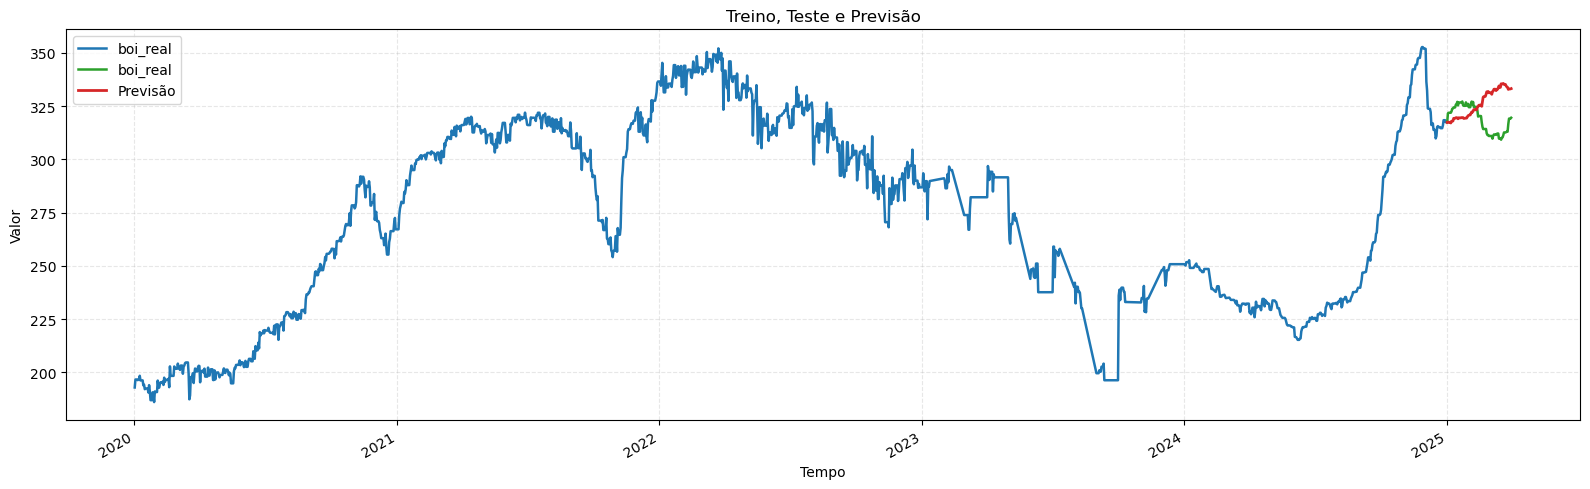

In [29]:
plot_forecast(y_ts_train, y_ts_test, res_optuna)

In [30]:
from joblib import dump, load

dump(res_optuna, "modelos/modelo_optuna.joblib")
loaded_model_optuna = load("modelos/modelo_optuna.joblib")

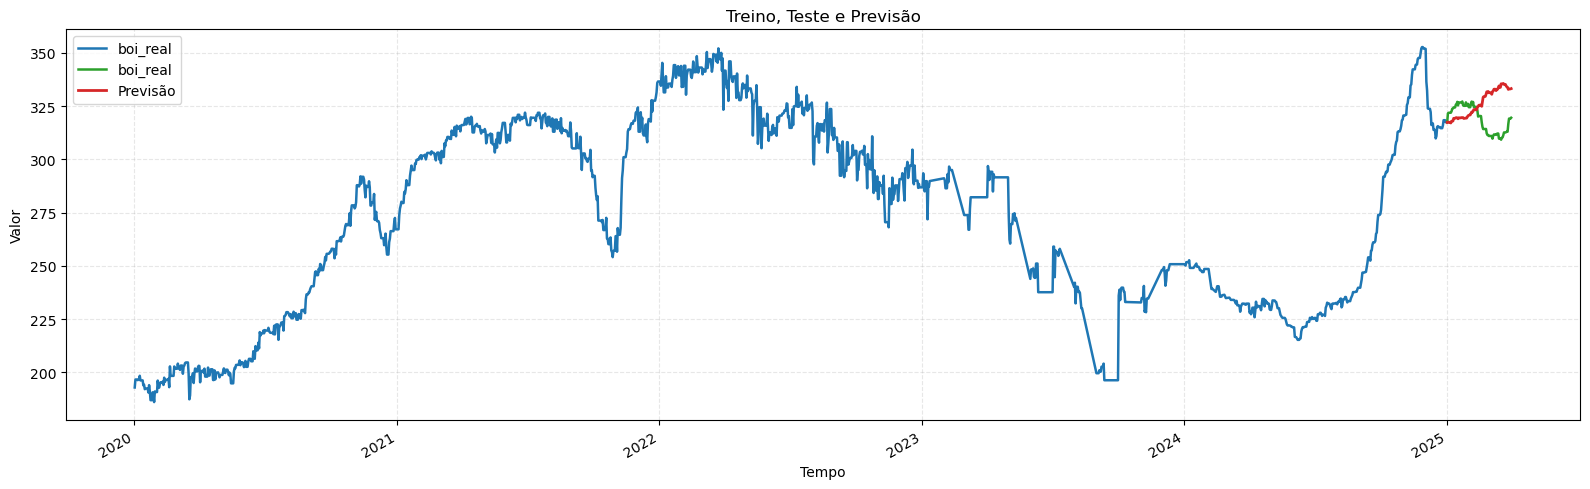

In [31]:
plot_forecast(y_ts_train, y_ts_test, loaded_model_optuna)

## Prophet

In [32]:
from prophet import Prophet


Importing plotly failed. Interactive plots will not work.


In [33]:
y.index.shape

(1660,)

In [34]:
y.values.shape

(1660,)

In [35]:
df = pd.DataFrame()

In [36]:
df['ds'] = y.index
df['y'] = y.values

In [37]:
df.head()

,ds,y
0,2020-01-02,192.95
1,2020-01-03,196.70
2,2020-01-04,196.70
3,2020-01-05,196.70
4,2020-01-06,196.40


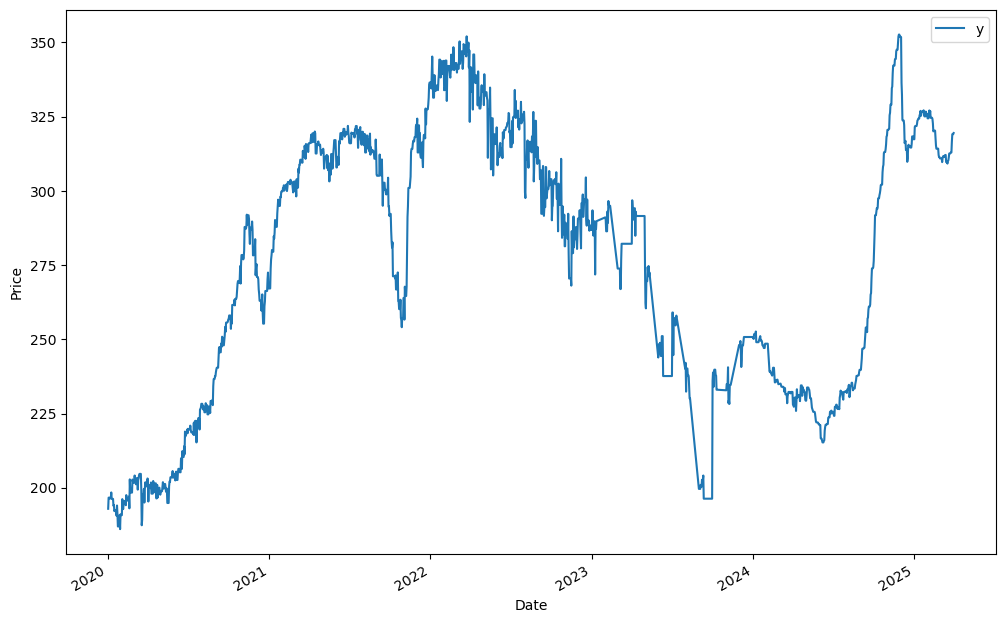

In [38]:
ax = df.set_index('ds').plot(figsize=(12, 8))
ax.set_ylabel('Price')
ax.set_xlabel('Date')

plt.show()

In [39]:
prophet_model = Prophet(growth='linear', interval_width=0.95)

In [40]:
prophet_model.fit(df)

08:44:10 - cmdstanpy - INFO - Chain [1] start processing
08:44:10 - cmdstanpy - INFO - Chain [1] done processing


In [42]:
dates_future = prophet_model.make_future_dataframe(periods=1, freq='MS')
dates_future.tail()

,ds
1656,2025-03-28
1657,2025-03-29
1658,2025-03-30
1659,2025-03-31
1660,2025-04-01


In [43]:
forecast = prophet_model.predict(dates_future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head()

,ds,yhat,yhat_lower,yhat_upper
0,2020-01-02,185.142282,163.124858,210.678014
1,2020-01-03,186.395366,161.557638,208.980248
2,2020-01-04,187.180402,163.328911,210.273838
3,2020-01-05,187.743628,165.760170,210.288707
4,2020-01-06,189.136382,164.054691,211.798890


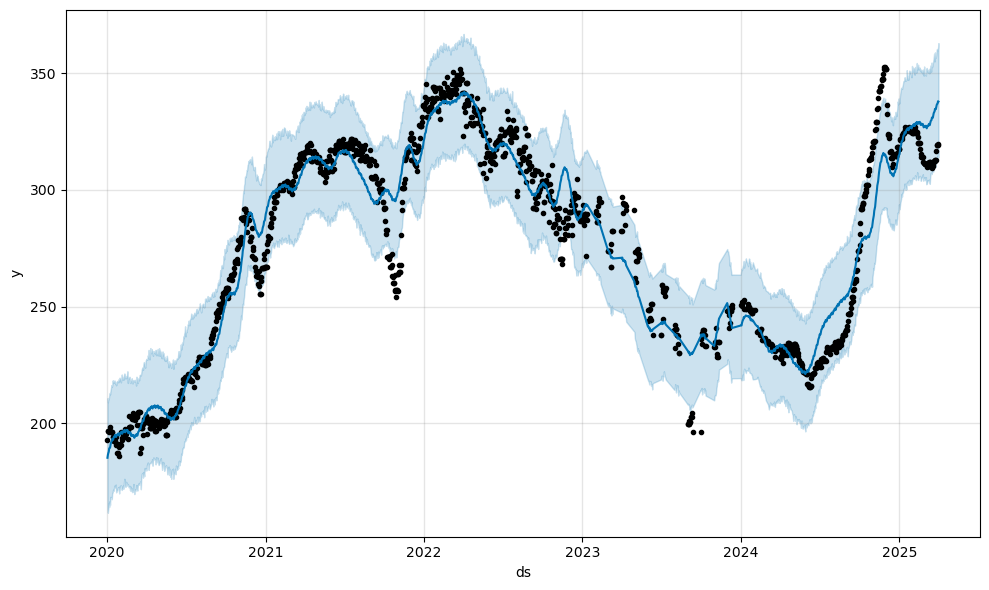

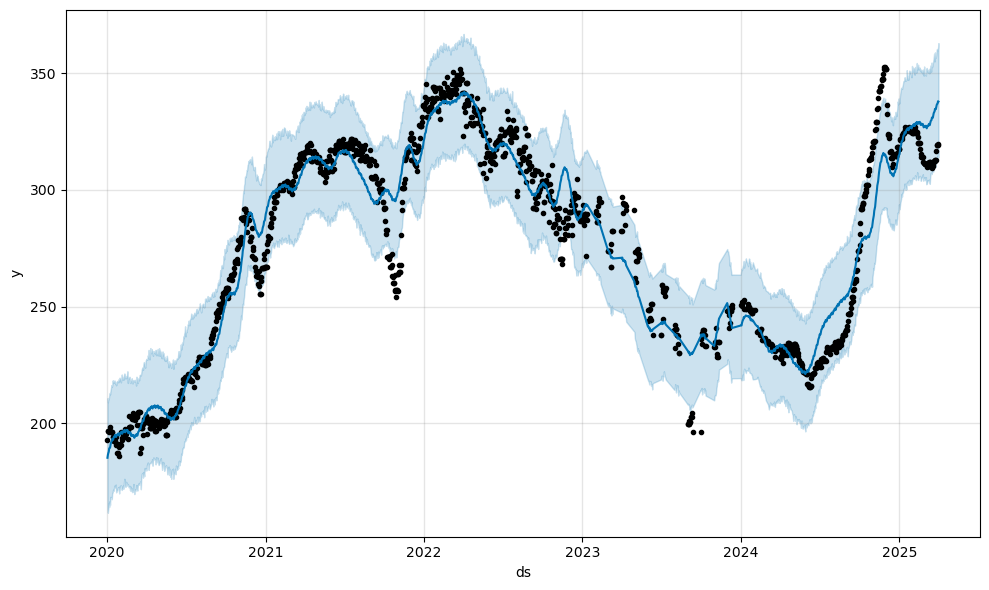

In [44]:
prophet_model.plot(forecast)

In [45]:
dump(prophet_model, "modelos/prophet_model.joblib")

['modelos/prophet_model.joblib']

### Exponential Smoothing Time Series (ETS)

In [46]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [47]:
# Fit the ETS model (Exponential Smoothing)
ets_model = ExponentialSmoothing(y, seasonal='add', trend=None, seasonal_periods=90)
ets_fit = ets_model.fit()

c:\Users\rmoreir\AppData\Local\miniconda3\envs\agro_proj_01\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\rmoreir\AppData\Local\miniconda3\envs\agro_proj_01\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


In [48]:
df_forecast = pd.DataFrame()
forecast = ets_fit.forecast(steps=90)
df_forecast.index = pd.to_datetime(y_ts_test.index[:90])
df_forecast['forecast'] = forecast.values
df_forecast.head()

c:\Users\rmoreir\AppData\Local\miniconda3\envs\agro_proj_01\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


,forecast
data,
2025-01-01,318.883008
2025-01-02,320.155896
2025-01-03,319.113203
2025-01-04,318.123024
2025-01-05,317.747333


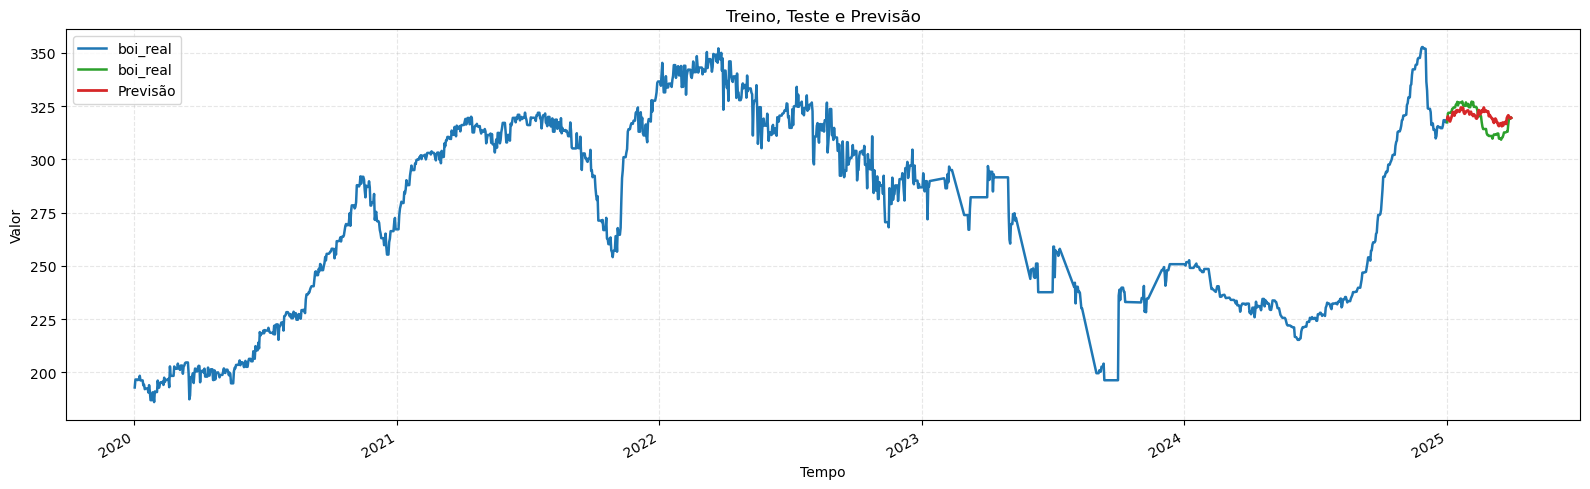

In [49]:
plot_forecast(y_ts_train, y_ts_test, df_forecast['forecast'])

In [50]:
dump(ets_model, "modelos/ets_model.joblib")

['modelos/ets_model.joblib']

### Long Short-Term Memory (LSTM)

In [12]:
y = pd.read_csv('df_normalized.csv', index_col='data')
#y.drop('Unnamed: 0', axis=1, inplace=True)
y.columns

Index(['CovidPeriodFlag', 'ano_novo_flag', 'carnaval_core_flag',
       'carnaval_window_flag', 'pascoa_flag', 'pascoa_window_flag',
       'dias_maes_flag', 'dias_maes_weekend_flag', 'festas_juninas_flag',
       'santo_antonio_flag', 'sao_joao_flag', 'sao_pedro_flag',
       'ferias_midyear_flag', 'ferias_verao_flag', 'dias_pais_flag',
       'dias_pais_weekend_flag', 'independencia_flag',
       'independencia_window_flag', 'dia_criancas_flag', 'finados_flag',
       'finados_weekend_flag', 'natal_flag', 'natal_window_flag',
       'fim_ano_window_flag', 'sazonal_carne_weight', 'scpdsi_goias',
       'precip_total_mm', 'TEMPERATURA', 'ipca', 'selic', 'PIB', 'PIB_Agro',
       'cme_valor', 'cme_Vol.', 'boi_futuro', 'boi_futuro_Vol.', 'boi_real',
       'boi_dolar', 'soja_real', 'soja_dolar', 'soja_futuro', 'soja_Vol.',
       'milho_futuro', 'milho_Vol.', 'milho_real', 'milho_dolar', 'taxa',
       'ciclo_MENOR_TX_NASC', 'ciclo_NASC_COMPLEMENTARES',
       'ciclo_PICO_NASCIMENTOS', '

In [13]:
cols = ['boi_real', 'boi_dolar','CovidPeriodFlag', 'TEMPERATURA', 'ipca', 'selic', 'PIB', 'cme_valor', 'soja_real', 'soja_dolar', 'soja_futuro', 'milho_futuro', 'milho_real', 'milho_dolar', 'taxa', 'el_nino_encoded']

In [14]:
y_feat_selected = y[cols]
y_feat_selected.columns.to_list()

['boi_real',
 'boi_dolar',
 'CovidPeriodFlag',
 'TEMPERATURA',
 'ipca',
 'selic',
 'PIB',
 'cme_valor',
 'soja_real',
 'soja_dolar',
 'soja_futuro',
 'milho_futuro',
 'milho_real',
 'milho_dolar',
 'taxa',
 'el_nino_encoded']

In [15]:
y_feat_selected.to_csv('df_feat_selected.csv')

In [16]:
y_feat_selected['boi_real'].head()

data
2020-01-02    192.95
2020-01-03    196.70
2020-01-04    196.70
2020-01-05    196.70
2020-01-06    196.40
Name: boi_real, dtype: float64

In [17]:
from sklearn.preprocessing import MinMaxScaler
import joblib
# Extract the values of the target column
features = cols
targets = TARGET

# Normalize the data
scaler_input = MinMaxScaler()
scaler_target = MinMaxScaler()

df_X_scaled = scaler_input.fit_transform(y_feat_selected[features])
df_y_scaled = scaler_target.fit_transform(y_feat_selected[[targets]])   

#y[features] = pd.DataFrame(scaled_data, index=prices.index, columns=['scaled_boi_real'])
# Display the first few scaled values
print(df_X_scaled[:5])
print(df_y_scaled[:5])

[[0.04112879 0.36250312 0.         0.42821868 0.48888748 0.61249512
  0.48833103 0.64341538 0.56720996 0.55575152 0.36164815 0.60159092
  0.57517931 0.64151649 0.         0.5       ]
 [0.06364455 0.37671404 0.         0.42821868 0.48888748 0.61249512
  0.48833103 0.64341538 0.56720996 0.55575152 0.36164815 0.60159092
  0.57517931 0.64151649 0.0117452  0.5       ]
 [0.06364455 0.37671404 0.         0.47171319 0.48888748 0.61249512
  0.48833103 0.58714046 0.52300101 0.54319305 0.40468578 0.63395022
  0.54014908 0.62899742 0.0117452  0.5       ]
 [0.06364455 0.37671404 0.         0.51463594 0.48888748 0.61249512
  0.48833103 0.58714046 0.52300101 0.54319305 0.40468578 0.63395022
  0.54014908 0.62899742 0.0117452  0.5       ]
 [0.06184329 0.36948392 0.         0.45234949 0.48888748 0.61249512
  0.48833103 0.6042479  0.48926708 0.47998373 0.41485644 0.62215916
  0.54570589 0.61278497 0.01021192 0.5       ]]
[[0.04112879]
 [0.06364455]
 [0.06364455]
 [0.06364455]
 [0.06184329]]


In [18]:

joblib.dump(scaler_input, "artifacts/input_scaler.gz")
joblib.dump(scaler_target, "artifacts/target_scaler.gz")

['artifacts/target_scaler.gz']

In [19]:
y_feat_selected.index.to_list()

['2020-01-02',
 '2020-01-03',
 '2020-01-04',
 '2020-01-05',
 '2020-01-06',
 '2020-01-07',
 '2020-01-08',
 '2020-01-09',
 '2020-01-10',
 '2020-01-11',
 '2020-01-12',
 '2020-01-13',
 '2020-01-14',
 '2020-01-15',
 '2020-01-16',
 '2020-01-17',
 '2020-01-18',
 '2020-01-19',
 '2020-01-20',
 '2020-01-21',
 '2020-01-22',
 '2020-01-23',
 '2020-01-24',
 '2020-01-26',
 '2020-01-27',
 '2020-01-28',
 '2020-01-29',
 '2020-01-30',
 '2020-01-31',
 '2020-02-01',
 '2020-02-02',
 '2020-02-03',
 '2020-02-04',
 '2020-02-05',
 '2020-02-06',
 '2020-02-07',
 '2020-02-08',
 '2020-02-09',
 '2020-02-10',
 '2020-02-11',
 '2020-02-12',
 '2020-02-13',
 '2020-02-14',
 '2020-02-15',
 '2020-02-16',
 '2020-02-17',
 '2020-02-18',
 '2020-02-19',
 '2020-02-20',
 '2020-02-21',
 '2020-02-22',
 '2020-02-23',
 '2020-02-24',
 '2020-02-25',
 '2020-02-26',
 '2020-02-27',
 '2020-02-28',
 '2020-02-29',
 '2020-03-01',
 '2020-03-02',
 '2020-03-03',
 '2020-03-04',
 '2020-03-05',
 '2020-03-06',
 '2020-03-07',
 '2020-03-08',
 '2020-03-

In [20]:
# Create a function to convert data into sequences for LSTM

def create_sequences_df(X, y, list_dates, time_steps=30):
    """
    Cria sequências para LSTM a partir de um DataFrame com datas.
    
    Retorna:
    X, y, dates -> arrays para LSTM e lista de datas correspondentes ao y
    """
    X_seq, y_seq, dates = [], [], []
    
    for i in range(X.shape[0] - time_steps):
        X_seq.append(X[i:i+time_steps])
        y_seq.append(y[i+time_steps])
        dates.append(list_dates[i+time_steps])  # guarda a data do target
    
    return np.array(X_seq), np.array(y_seq), dates


# Use 90 time steps to predict the next value
time_steps = 90
X, y, y_dates = create_sequences_df(df_X_scaled, df_y_scaled, y_feat_selected.index.to_list(), time_steps=time_steps)

# Ajusta formato para LSTM
# X = X.reshape(X.shape[0], X.shape[1], 1)

In [44]:
print(X.shape, y.shape, len(y_dates))

(1570, 90, 16) (1570, 1) 1570


In [21]:
# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
y_dates_train, y_dates_test = y_dates[:train_size], y_dates[train_size:]

In [25]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)
print(len(y_dates_train), len(y_dates_test)) 

(1256, 90, 16) (1256, 1)
(314, 90, 16) (314, 1)
1256 314


In [23]:
y_test[-1]
scaler_target.inverse_transform(y_test[-1].reshape(-1, 1))

array([[319.5]])

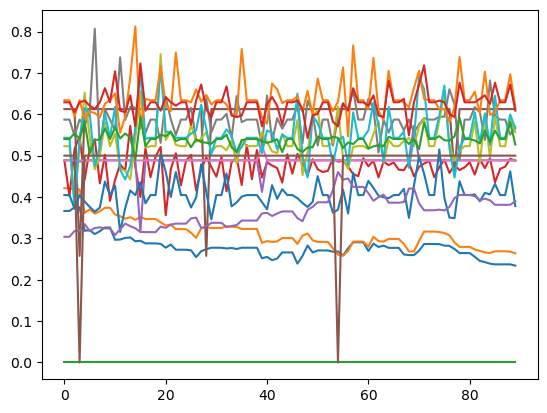

In [16]:
plt.plot(X_test[0])
plt.show()

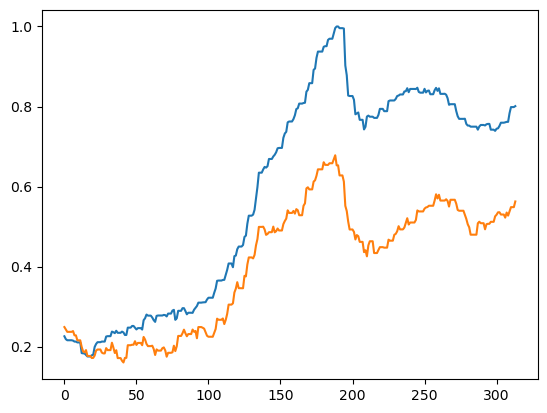

In [17]:
plt.plot(y_test)
plt.show()

In [24]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Input, Dropout
from keras.optimizers import Adam


def objective(trial):
    # Hiperparâmetros a otimizar
    n_units = trial.suggest_int('n_units', 32, 128)
    dropout_rate = trial.suggest_float('dropout', 0.2, 0.5)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])

    # Modelo
    model = Sequential([
        LSTM(n_units, input_shape=(time_steps, X_train.shape[2]), return_sequences=False),
        Dropout(dropout_rate),
        Dense(y_train.shape[1])  # saída multivariada
    ])
    model.compile(optimizer=Adam(learning_rate=lr), loss='mse')

    # Treino rápido para avaliação
    history = model.fit(X_train, y_train,
                        validation_data=(X_test, y_test),
                        epochs=20, batch_size=batch_size, verbose=0)

    # Retorna a menor val_loss
    return min(history.history['val_loss'])


In [25]:
# Executa a otimização
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30)

[I 2025-12-18 10:08:44,840] A new study created in memory with name: no-name-3b06d228-15dd-4f97-9c62-a9e7f2531541
[I 2025-12-18 10:09:11,529] Trial 0 finished with value: 0.0021605435758829117 and parameters: {'n_units': 44, 'dropout': 0.34859177719659445, 'lr': 0.0006611246492509334, 'batch_size': 16}. Best is trial 0 with value: 0.0021605435758829117.
[I 2025-12-18 10:09:41,377] Trial 1 finished with value: 0.0006374588119797409 and parameters: {'n_units': 84, 'dropout': 0.21406127185887924, 'lr': 0.0011122208879049483, 'batch_size': 16}. Best is trial 1 with value: 0.0006374588119797409.
[I 2025-12-18 10:09:57,552] Trial 2 finished with value: 0.016503192484378815 and parameters: {'n_units': 36, 'dropout': 0.4216453086889407, 'lr': 0.00027703268808345987, 'batch_size': 32}. Best is trial 1 with value: 0.0006374588119797409.
[I 2025-12-18 10:10:14,441] Trial 3 finished with value: 0.0010878948960453272 and parameters: {'n_units': 81, 'dropout': 0.48581774228811414, 'lr': 0.0015402657

In [26]:
print("Melhores parâmetros:", study.best_params)

Melhores parâmetros: {'n_units': 69, 'dropout': 0.37664454557415733, 'lr': 0.004228756987115896, 'batch_size': 16}


In [27]:
# {'n_units': 112, 'dropout': 0.0795423173696612, 'lr': 0.0039122869325709814, 'batch_size': 16}
# {'n_units': 68, 'dropout': 0.11690713500768368, 'lr': 0.008629428593827423, 'batch_size': 32}
# {'n_units': 93, 'dropout': 0.32786203265659175, 'lr': 0.00490945521680098, 'batch_size': 16}
# {'n_units': 90, 'dropout': 0.36142963355733754, 'lr': 0.002248104508083213, 'batch_size': 16}
# {'n_units': 69, 'dropout': 0.37664454557415733, 'lr': 0.004228756987115896, 'batch_size': 16}
model = Sequential([
    LSTM(study.best_params['n_units'], input_shape=(time_steps, X_train.shape[2]), return_sequences=False),
    Dropout(study.best_params['dropout']),
    Dense(y_train.shape[1])  # saída multivariada
])
model.compile(optimizer=Adam(learning_rate=study.best_params['lr']), loss='mse')

In [28]:
history = model.fit(X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=30, batch_size=study.best_params['batch_size'])

Epoch 1/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 0.0369 - val_loss: 0.0182
Epoch 2/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0082 - val_loss: 0.0200
Epoch 3/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0077 - val_loss: 0.0109
Epoch 4/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0065 - val_loss: 0.0058
Epoch 5/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0052 - val_loss: 7.3576e-04
Epoch 6/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0046 - val_loss: 0.0019
Epoch 7/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0046 - val_loss: 0.0015
Epoch 8/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0044 - val_loss: 0.0012
Epoch 9/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0039 - val_loss: 0.0033
Epoch 10/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0042 - val_loss: 0.0033
Epoch 11/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0036 - val_loss: 0.0037
Epoch 12/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss:

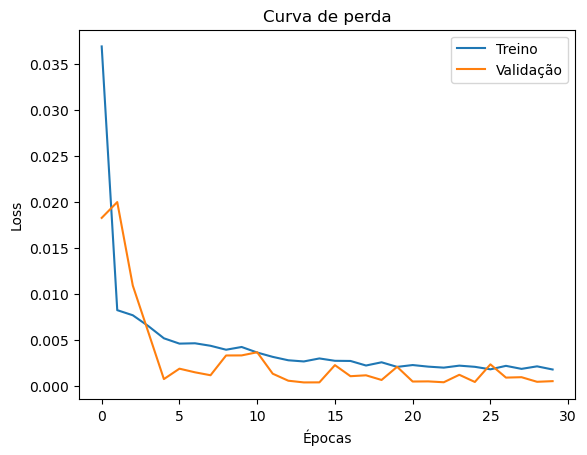

In [29]:
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
plt.title('Curva de perda')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [30]:
# Make predictions on the test data
y_pred = model.predict(X_test)

# Inverse transform the predictions and actual values to original scale
y_train_rescaled = scaler_target.inverse_transform(y_train)
y_pred_rescaled = scaler_target.inverse_transform(y_pred)
y_test_rescaled = scaler_target.inverse_transform(y_test)

# Display the first few predicted and actual values
print(y_pred_rescaled[:5])
print(y_test_rescaled[:5])

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
[[225.53989]
 [225.15439]
 [224.09958]
 [223.2501 ]
 [222.59807]]
[[223.7 ]
 [222.5 ]
 [222.05]
 [222.05]
 [222.05]]


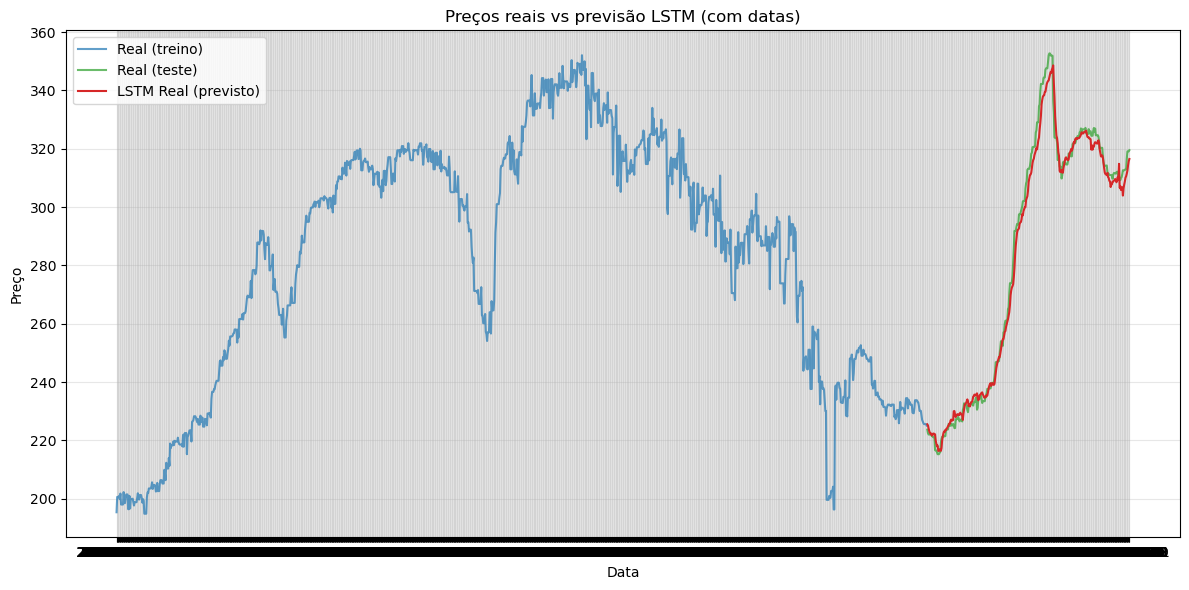

In [31]:
#last_window_dates = pd.date_range(end=y_dates_test[-1], periods=time_steps)

plt.figure(figsize=(12, 6))

#plt.plot(last_window_dates, X_test_rescaled, label='Última janela X_test', color='tab:orange', linestyle='--')
plt.plot(y_dates_train, y_train_rescaled[:, 0], label='Real (treino)', color='tab:blue', alpha=0.7)
#plt.plot(y_dates_train, y_train_rescaled[:, 1], label='Dólar (treino)', color='tab:gray', alpha=0.7)

plt.plot(y_dates_test,  y_test_rescaled[:, 0],  label='Real (teste)', color='tab:green', alpha=0.7)
#plt.plot(y_dates_test,  y_test_rescaled[:, 1],  label='Dólar (teste)', color='tab:orange', alpha=0.7)

plt.plot(y_dates_test,  y_pred_rescaled[:, 0],  label='LSTM Real (previsto)', color='tab:red')
#plt.plot(y_dates_test,  y_pred_rescaled[:, 1],  label='LSTM Dólar (previsto)', color='tab:purple')

plt.title('Preços reais vs previsão LSTM (com datas)')
plt.xlabel('Data')
plt.ylabel('Preço')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [32]:
from joblib import dump, load

#dump(model, "modelos/lstm_model.joblib")
model.save("modelos/lstm_model.keras")

## Modelos Supervisionados 

### 1. Random Forest

In [289]:

from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

In [351]:
df_sel = pd.read_csv('df_agro.csv', index_col='data')
df_sel.drop('Unnamed: 0', axis=1, inplace=True)
df_sel.head()

,CovidPeriodFlag,tarifa_base_carne,tarifa_adicional_trump,tarifas_carne_total,Year,Month,DayOfWeek,ano_novo_flag,carnaval_core_flag,carnaval_window_flag,...,milho_Vol.,milho_real,milho_dolar,taxa,ciclo_MENOR_TX_NASC,ciclo_NASC_COMPLEMENTARES,ciclo_PICO_NASCIMENTOS,aspecto_PLANEJAMENTO,aspecto_SAFRA,el_nino_encoded
data,,,,,,,,,,,,,,,,,,,,,
2020-01-02,0,26.4,0.0,26.4,2020.0,1.0,3.0,0.0,0.0,0.0,...,103990.0,48.43,12.04,4.0260,0,0,1,1,0,0
2020-01-03,0,26.4,0.0,26.4,2020.0,1.0,4.0,0.0,0.0,0.0,...,125930.0,48.91,12.07,4.0669,0,0,1,1,0,0
2020-01-04,0,26.4,0.0,26.4,2020.0,1.0,5.0,0.0,0.0,0.0,...,125930.0,48.91,12.07,4.0669,0,0,1,1,0,0
2020-01-05,0,26.4,0.0,26.4,2020.0,1.0,6.0,0.0,0.0,0.0,...,125930.0,48.91,12.07,4.0669,0,0,1,1,0,0
2020-01-06,0,26.4,0.0,26.4,2020.0,1.0,0.0,0.0,0.0,0.0,...,112130.0,48.99,12.03,4.0616,0,0,1,1,0,0


In [352]:
df_sel.columns

Index(['CovidPeriodFlag', 'tarifa_base_carne', 'tarifa_adicional_trump',
       'tarifas_carne_total', 'Year', 'Month', 'DayOfWeek', 'ano_novo_flag',
       'carnaval_core_flag', 'carnaval_window_flag', 'pascoa_flag',
       'pascoa_window_flag', 'dias_maes_flag', 'dias_maes_weekend_flag',
       'festas_juninas_flag', 'santo_antonio_flag', 'sao_joao_flag',
       'sao_pedro_flag', 'ferias_midyear_flag', 'ferias_verao_flag',
       'dias_pais_flag', 'dias_pais_weekend_flag', 'independencia_flag',
       'independencia_window_flag', 'dia_criancas_flag', 'finados_flag',
       'finados_weekend_flag', 'natal_flag', 'natal_window_flag',
       'fim_ano_window_flag', 'sazonal_carne_weight', 'scpdsi_goias',
       'precip_total_mm', 'TEMPERATURA', 'ipca', 'selic', 'PIB', 'PIB_Agro',
       'cme_valor', 'cme_Vol.', 'boi_futuro', 'boi_futuro_Vol.', 'boi_real',
       'boi_dolar', 'soja_real', 'soja_dolar', 'soja_futuro', 'soja_Vol.',
       'milho_futuro', 'milho_Vol.', 'milho_real', 'milho_do

In [353]:
X = df_sel.drop(columns=['boi_real', 'boi_dolar'])
y = df_sel[['boi_real','boi_dolar']]
y_dates = y.index

In [354]:
# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
y_dates_train, y_dates_test = y_dates[:train_size], y_dates[train_size:]

In [355]:
len(y_dates_test)

332

In [356]:
tscv = TimeSeriesSplit(n_splits=5)

In [ ]:
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 100, 1000)
    max_depth = trial.suggest_int('max_depth', 5, 50)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 5)
    max_features = trial.suggest_categorical('max_features',['sqrt', 'log2'])

    # Modelo
    base_rf = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42,
        n_jobs=-1
    )

    model = MultiOutputRegressor(base_rf)

    # Validação cruzada (ou use TimeSeriesSplit para séries temporais)
    score = cross_val_score(model, X_train, y_train, cv=tscv, scoring='neg_root_mean_squared_error')
    return -score.mean()


In [358]:
# Cria estudo
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30)

[I 2025-12-03 13:44:51,358] A new study created in memory with name: no-name-9a7fe360-4907-4ba7-8ffc-3b444473ee11


[I 2025-12-03 13:45:02,499] Trial 0 finished with value: 21.906612750146262 and parameters: {'n_estimators': 823, 'max_depth': 28, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': 'log2'}. Best is trial 0 with value: 21.906612750146262.
[I 2025-12-03 13:45:15,093] Trial 1 finished with value: 21.598600577838386 and parameters: {'n_estimators': 928, 'max_depth': 21, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 1 with value: 21.598600577838386.
[I 2025-12-03 13:45:26,567] Trial 2 finished with value: 21.554361832694646 and parameters: {'n_estimators': 842, 'max_depth': 15, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 2 with value: 21.554361832694646.
[I 2025-12-03 13:45:29,093] Trial 3 finished with value: 21.850618045761607 and parameters: {'n_estimators': 141, 'max_depth': 22, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2'}. Best is trial 2 with value: 21.554361832694

In [359]:
print("Melhores parâmetros:", study.best_params)

Melhores parâmetros: {'n_estimators': 316, 'max_depth': 50, 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'sqrt'}


In [360]:
# Treina modelo final com melhores parâmetros
#X_test_flat = X_test.reshape(X_test.shape[0], -1)
#X_train_flat = X_train.reshape(X_train.shape[0], -1)
best_params = study.best_params

base_rf = RandomForestRegressor(
    **best_params,
    random_state=42,
    n_jobs=-1
)

best_model = MultiOutputRegressor(base_rf, n_jobs=-1)
best_model.fit(X_train, y_train)

MultiOutputRegressor(estimator=RandomForestRegressor(max_depth=50,
                                                     max_features='sqrt',
                                                     min_samples_leaf=2,
                                                     min_samples_split=9,
                                                     n_estimators=316,
                                                     n_jobs=-1,
                                                     random_state=42),
                     n_jobs=-1)

In [361]:
# Avalia no teste
y_pred = best_model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
print(f"RMSE no teste: {rmse:.3f}")


RMSE no teste: 28.806


In [362]:
y_train.head()

,boi_real,boi_dolar
data,,
2020-01-02,192.95,47.96
2020-01-03,196.70,48.53
2020-01-04,196.70,48.53
2020-01-05,196.70,48.53
2020-01-06,196.40,48.24


In [363]:
len(y_dates_train)

1328

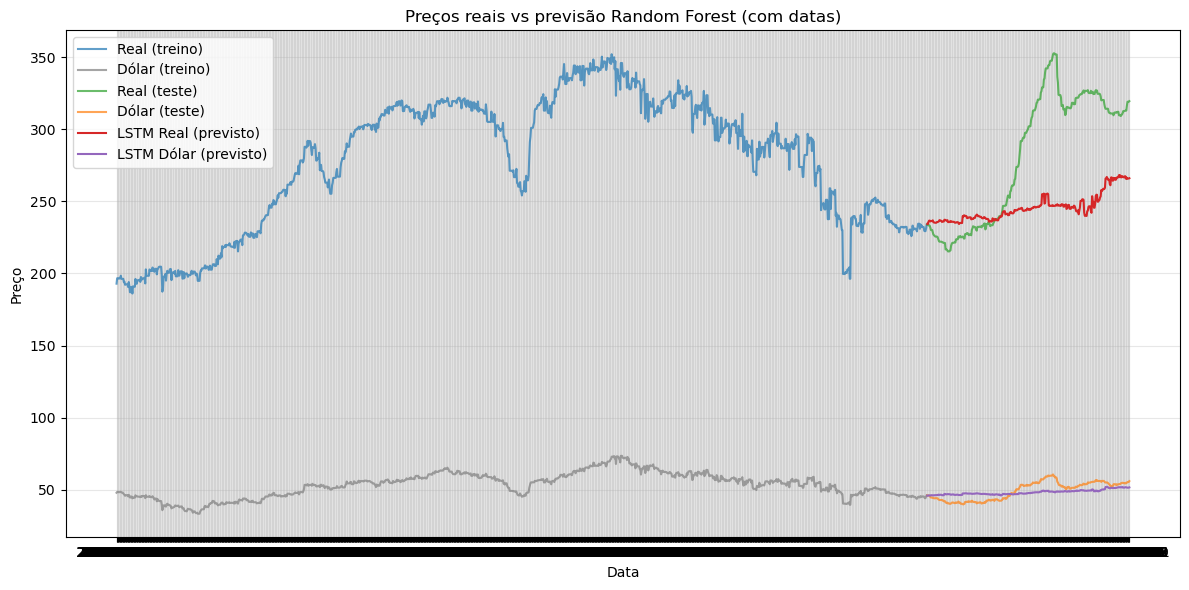

In [364]:
plt.figure(figsize=(12, 6))

plt.plot(y_dates_train, y_train.iloc[:, 0], label='Real (treino)', color='tab:blue', alpha=0.7)
plt.plot(y_dates_train, y_train.iloc[:, 1], label='Dólar (treino)', color='tab:gray', alpha=0.7)

plt.plot(y_dates_test,  y_test.iloc[:, 0],  label='Real (teste)', color='tab:green', alpha=0.7)
plt.plot(y_dates_test,  y_test.iloc[:, 1],  label='Dólar (teste)', color='tab:orange', alpha=0.7)

plt.plot(y_dates_test,  y_pred[:, 0],  label='LSTM Real (previsto)', color='tab:red')
plt.plot(y_dates_test,  y_pred[:, 1],  label='LSTM Dólar (previsto)', color='tab:purple')

plt.title('Preços reais vs previsão Random Forest (com datas)')
plt.xlabel('Data')
plt.ylabel('Preço')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [385]:
dump(best_model, "modelos/multi_rf_model.joblib")

['modelos/multi_rf_model.joblib']

### XGBoost

In [143]:
df_agro = pd.read_csv('df_agro.csv', index_col='data')
df_agro.index = pd.to_datetime(df_agro.index)
df_agro = df_agro.drop('Unnamed: 0', axis=1)
df_agro.columns

Index(['CovidPeriodFlag', 'tarifa_base_carne', 'tarifa_adicional_trump',
       'tarifas_carne_total', 'Year', 'Month', 'DayOfWeek', 'ano_novo_flag',
       'carnaval_core_flag', 'carnaval_window_flag', 'pascoa_flag',
       'pascoa_window_flag', 'dias_maes_flag', 'dias_maes_weekend_flag',
       'festas_juninas_flag', 'santo_antonio_flag', 'sao_joao_flag',
       'sao_pedro_flag', 'ferias_midyear_flag', 'ferias_verao_flag',
       'dias_pais_flag', 'dias_pais_weekend_flag', 'independencia_flag',
       'independencia_window_flag', 'dia_criancas_flag', 'finados_flag',
       'finados_weekend_flag', 'natal_flag', 'natal_window_flag',
       'fim_ano_window_flag', 'sazonal_carne_weight', 'scpdsi_goias',
       'precip_total_mm', 'TEMPERATURA', 'ipca', 'selic', 'PIB', 'PIB_Agro',
       'cme_valor', 'cme_Vol.', 'boi_futuro', 'boi_futuro_Vol.', 'boi_real',
       'boi_dolar', 'soja_real', 'soja_dolar', 'soja_futuro', 'soja_Vol.',
       'milho_futuro', 'milho_Vol.', 'milho_real', 'milho_do

In [144]:
def make_lag_features(df, cols=('boi_real', 'boi_dolar'), lags=(1,2,3,7,14,30)):
    out = pd.DataFrame(index=df.index)
    for col in cols:
        out[col] = df[col]
        for L in lags:
            out[f'{col}_lag{L}'] = df[col].shift(L)
    return out.dropna()


data = make_lag_features(df_agro, cols=('boi_real', 'boi_dolar'))
X = data.drop(columns=['boi_real', 'boi_dolar'])
y = data[['boi_real', 'boi_dolar']]

In [452]:
tscv = TimeSeriesSplit(n_splits=5)

In [454]:
import xgboost as xgb
from sklearn.multioutput import MultiOutputRegressor

def objective(trial):

    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 5),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 5)
    }


    # Modelo XGBoost
    base_rf = xgb.XGBRegressor(
        **params,
        random_state=42,
        n_jobs=-1
    )

    model = MultiOutputRegressor(base_rf)

    # Avaliação com cross-validation
    score = cross_val_score(model, X, y, cv=tscv, scoring='neg_root_mean_squared_error')
    return -score.mean()  # Optuna minimiza, então retornamos RMSE positivo

In [455]:

# Cria estudo
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

[I 2025-12-02 15:24:32,907] A new study created in memory with name: no-name-5b631cee-53c9-46c9-9215-05b7e513999b
[I 2025-12-02 15:24:35,154] Trial 0 finished with value: 8.492828178405762 and parameters: {'n_estimators': 196, 'max_depth': 12, 'learning_rate': 0.08311676499014614, 'subsample': 0.5518874993608849, 'colsample_bytree': 0.8985291011962948, 'gamma': 0.9313761838765877, 'reg_alpha': 4.438601285845439, 'reg_lambda': 1.0409315891150213}. Best is trial 0 with value: 8.492828178405762.
[I 2025-12-02 15:24:39,731] Trial 1 finished with value: 8.263492631912232 and parameters: {'n_estimators': 801, 'max_depth': 9, 'learning_rate': 0.025065857301987297, 'subsample': 0.8126802688951811, 'colsample_bytree': 0.8322760836116272, 'gamma': 4.187954825351933, 'reg_alpha': 0.6482077703752881, 'reg_lambda': 3.775924034853453}. Best is trial 1 with value: 8.263492631912232.
[I 2025-12-02 15:24:41,467] Trial 2 finished with value: 8.449120378494262 and parameters: {'n_estimators': 233, 'max_d

In [456]:
print("Melhores parâmetros:", study.best_params)

Melhores parâmetros: {'n_estimators': 422, 'max_depth': 3, 'learning_rate': 0.13021519465486292, 'subsample': 0.9220401199528963, 'colsample_bytree': 0.7544832406249742, 'gamma': 1.7650531832609553, 'reg_alpha': 1.729224475760038, 'reg_lambda': 4.339514197348438}


In [457]:
# Treina modelo final com melhores parâmetros
best_params = study.best_params

base_rf = xgb.XGBRegressor(
    **best_params,
    random_state=42,
    n_jobs=-1
)

best_model = MultiOutputRegressor(base_rf, n_jobs=-1)
best_model.fit(X, y)

MultiOutputRegressor(estimator=XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=0.7544832406249742,
                                            device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None,
                                            feature_weights=None,
                                            gamma=1.7650531832609553,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=0.13021519465486292,
                                            max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=3,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=422, n_jobs=-1,
                                            num_parallel_tree=None, ...),
                     n_jobs=-1)

In [480]:
horizon = 90
last_vals_real = df_agro['boi_real'].copy()
last_vals_dolar = df_agro['boi_dolar'].copy()
last_features = X.iloc[-1].copy()
preds_real, preds_dolar = [], []
dates = pd.date_range(df_agro.index[-1] + pd.Timedelta(days=1), periods=horizon, freq='D')

In [481]:
for d in dates:
    # Atualiza lags para boi_real
    for L in [1,2,3,7,14,30]:
        key_real = f'boi_real_lag{L}'
        key_dolar = f'boi_dolar_lag{L}'
        last_features[key_real] = last_vals_real.iloc[-L] if len(last_vals_real) >= L else last_vals_real.iloc[-1]
        last_features[key_dolar] = last_vals_dolar.iloc[-L] if len(last_vals_dolar) >= L else last_vals_dolar.iloc[-1]

    y_hat = best_model.predict([last_features.values])[0]  # [boi_real, boi_dolar]
    preds_real.append(y_hat[0])
    preds_dolar.append(y_hat[1])

    # Atualiza histórico
    last_vals_real = pd.concat([last_vals_real, pd.Series([y_hat[0]], index=[d])])
    last_vals_dolar = pd.concat([last_vals_dolar, pd.Series([y_hat[1]], index=[d])])

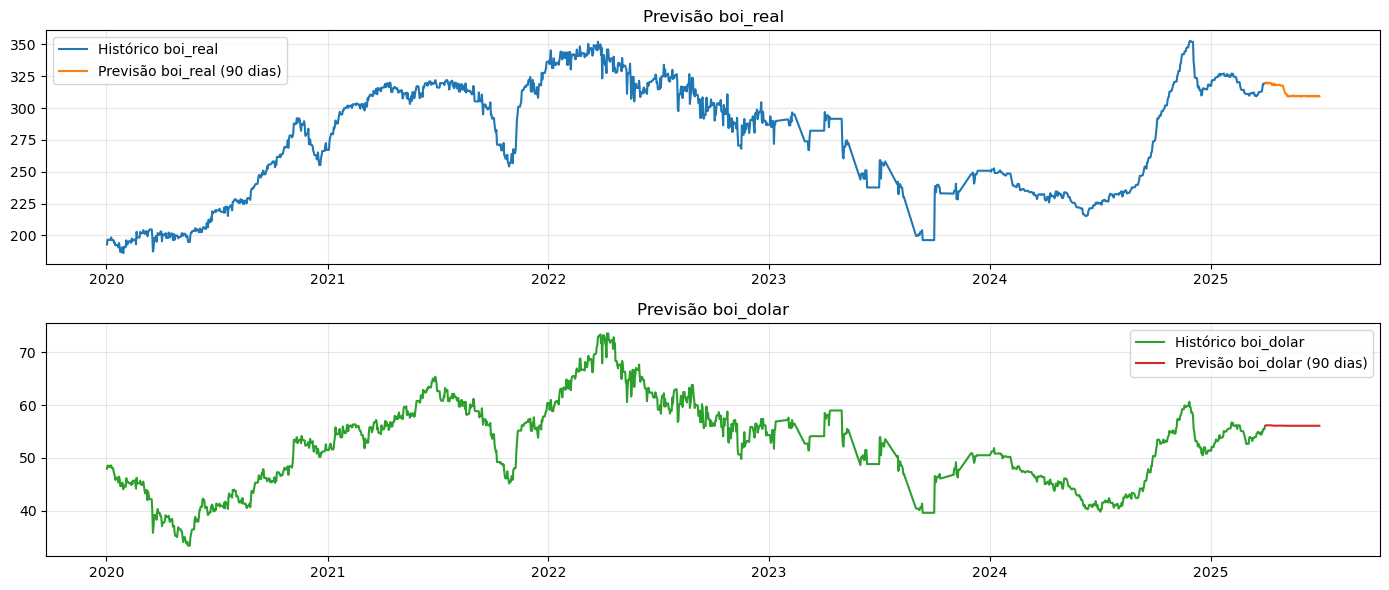

In [482]:
# -----------------------------
# 7) Plot histórico + previsão
# -----------------------------
plt.figure(figsize=(14,6))

plt.subplot(2,1,1)
plt.plot(df_agro.index, df_agro['boi_real'], label='Histórico boi_real', color='tab:blue')
plt.plot(dates, preds_real, label='Previsão boi_real (90 dias)', color='tab:orange')
plt.title('Previsão boi_real')
plt.legend(); plt.grid(alpha=0.3)

plt.subplot(2,1,2)
plt.plot(df_agro.index, df_agro['boi_dolar'], label='Histórico boi_dolar', color='tab:green')
plt.plot(dates, preds_dolar, label='Previsão boi_dolar (90 dias)', color='tab:red')
plt.title('Previsão boi_dolar')
plt.legend(); plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [483]:
dump(best_model, "modelos/xboot_model.joblib")

['modelos/xboot_model.joblib']

### Support Vector Regression

In [63]:
from sklearn.preprocessing import StandardScaler

In [202]:
df_sel = pd.read_csv('df_normalized.csv', index_col='data')
df_sel.head()

,CovidPeriodFlag,ano_novo_flag,carnaval_core_flag,carnaval_window_flag,pascoa_flag,pascoa_window_flag,dias_maes_flag,dias_maes_weekend_flag,festas_juninas_flag,santo_antonio_flag,...,milho_Vol.,milho_real,milho_dolar,taxa,ciclo_MENOR_TX_NASC,ciclo_NASC_COMPLEMENTARES,ciclo_PICO_NASCIMENTOS,aspecto_PLANEJAMENTO,aspecto_SAFRA,el_nino_encoded
data,,,,,,,,,,,,,,,,,,,,,
2020-01-02,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.406033,0.575179,0.641516,0.000000,0,0,1,1,0,0.5
2020-01-03,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.455546,0.575179,0.641516,0.011745,0,0,1,1,0,0.5
2020-01-04,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.455546,0.540149,0.628997,0.011745,0,0,1,1,0,0.5
2020-01-05,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.455546,0.540149,0.628997,0.011745,0,0,1,1,0,0.5
2020-01-06,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.424853,0.545706,0.612785,0.010212,0,0,1,1,0,0.5


In [203]:
X = df_sel.drop(columns=['boi_real', 'boi_dolar'])
y = df_sel[['boi_real','boi_dolar']]

In [205]:
X.columns.to_list()

['CovidPeriodFlag',
 'ano_novo_flag',
 'carnaval_core_flag',
 'carnaval_window_flag',
 'pascoa_flag',
 'pascoa_window_flag',
 'dias_maes_flag',
 'dias_maes_weekend_flag',
 'festas_juninas_flag',
 'santo_antonio_flag',
 'sao_joao_flag',
 'sao_pedro_flag',
 'ferias_midyear_flag',
 'ferias_verao_flag',
 'dias_pais_flag',
 'dias_pais_weekend_flag',
 'independencia_flag',
 'independencia_window_flag',
 'dia_criancas_flag',
 'finados_flag',
 'finados_weekend_flag',
 'natal_flag',
 'natal_window_flag',
 'fim_ano_window_flag',
 'sazonal_carne_weight',
 'scpdsi_goias',
 'precip_total_mm',
 'TEMPERATURA',
 'ipca',
 'selic',
 'PIB',
 'PIB_Agro',
 'cme_valor',
 'cme_Vol.',
 'boi_futuro',
 'boi_futuro_Vol.',
 'soja_real',
 'soja_dolar',
 'soja_futuro',
 'soja_Vol.',
 'milho_futuro',
 'milho_Vol.',
 'milho_real',
 'milho_dolar',
 'taxa',
 'ciclo_MENOR_TX_NASC',
 'ciclo_NASC_COMPLEMENTARES',
 'ciclo_PICO_NASCIMENTOS',
 'aspecto_PLANEJAMENTO',
 'aspecto_SAFRA',
 'el_nino_encoded']

In [189]:
X.head()

,CovidPeriodFlag,ano_novo_flag,carnaval_core_flag,carnaval_window_flag,pascoa_flag,pascoa_window_flag,dias_maes_flag,dias_maes_weekend_flag,festas_juninas_flag,santo_antonio_flag,...,milho_Vol.,milho_real,milho_dolar,taxa,ciclo_MENOR_TX_NASC,ciclo_NASC_COMPLEMENTARES,ciclo_PICO_NASCIMENTOS,aspecto_PLANEJAMENTO,aspecto_SAFRA,el_nino_encoded
data,,,,,,,,,,,,,,,,,,,,,
2020-01-02,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.406033,0.575179,0.641516,0.000000,0,0,1,1,0,0.5
2020-01-03,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.455546,0.575179,0.641516,0.011745,0,0,1,1,0,0.5
2020-01-04,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.455546,0.540149,0.628997,0.011745,0,0,1,1,0,0.5
2020-01-05,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.455546,0.540149,0.628997,0.011745,0,0,1,1,0,0.5
2020-01-06,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.424853,0.545706,0.612785,0.010212,0,0,1,1,0,0.5


In [190]:
y.head()

,boi_real,boi_dolar
data,,
2020-01-02,192.95,47.96
2020-01-03,196.70,48.53
2020-01-04,196.70,48.53
2020-01-05,196.70,48.53
2020-01-06,196.40,48.24


In [191]:

# 2. Criar lags para cada série (usando 3 lags)
n_lags = 3
for col in X.columns:
    for i in range(1, n_lags + 1):
        X[f'{col}_lag_{i}'] = X[col].shift(i)

# Remover NaNs
X.dropna(inplace=True)
X.isna().sum().sum()

np.int64(0)

In [192]:
for col in y.columns:
    for i in range(1, n_lags + 1):
        y[f'{col}_lag_{i}'] = y[col].shift(i)


# Remover NaNs
y.dropna(inplace=True)
y.isna().sum().sum()

np.int64(0)

In [193]:
X.head()

,CovidPeriodFlag,ano_novo_flag,carnaval_core_flag,carnaval_window_flag,pascoa_flag,pascoa_window_flag,dias_maes_flag,dias_maes_weekend_flag,festas_juninas_flag,santo_antonio_flag,...,ciclo_PICO_NASCIMENTOS_lag_3,aspecto_PLANEJAMENTO_lag_1,aspecto_PLANEJAMENTO_lag_2,aspecto_PLANEJAMENTO_lag_3,aspecto_SAFRA_lag_1,aspecto_SAFRA_lag_2,aspecto_SAFRA_lag_3,el_nino_encoded_lag_1,el_nino_encoded_lag_2,el_nino_encoded_lag_3
data,,,,,,,,,,,,,,,,,,,,,
2020-01-05,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.5,0.5,0.5
2020-01-06,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.5,0.5,0.5
2020-01-07,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.5,0.5,0.5
2020-01-08,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.5,0.5,0.5
2020-01-09,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.5,0.5,0.5


In [194]:
y.head()

,boi_real,boi_dolar,boi_real_lag_1,boi_real_lag_2,boi_real_lag_3,boi_dolar_lag_1,boi_dolar_lag_2,boi_dolar_lag_3
data,,,,,,,,
2020-01-05,196.70,48.53,196.7,196.7,192.95,48.53,48.53,47.96
2020-01-06,196.40,48.24,196.7,196.7,196.70,48.53,48.53,48.53
2020-01-07,196.60,48.42,196.4,196.7,196.70,48.24,48.53,48.53
2020-01-08,196.70,48.58,196.6,196.4,196.70,48.42,48.24,48.53
2020-01-09,198.45,48.56,196.7,196.6,196.40,48.58,48.42,48.24


In [195]:
train_size = int(len(df_agro) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [196]:
y_dates_train = y_train.index

In [197]:
y_dates_test = y_test.index

In [198]:
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

In [199]:
from sklearn.svm import SVR

def objective(trial):

    params = {
        'kernel': trial.suggest_categorical('kernel', ['linear', 'poly', 'rbf', 'sigmoid']),
        'degree': trial.suggest_int('degree', 3, 15),
        'gamma': trial.suggest_categorical('gamma', ['scale','auto']),
        'C': trial.suggest_float('C', 0.1, 1.0),
        'epsilon': trial.suggest_float('epsilon', 1e-3, 1.0, log=True)
    }


    # Modelo XGBoost
    base_rf = SVR(
        **params
    )

    model = MultiOutputRegressor(base_rf)

    # Avaliação com cross-validation
    score = cross_val_score(model, X_train, y_train_scaled, cv=tscv, scoring='neg_root_mean_squared_error')
    return -score.mean()  # Optuna minimiza, então retornamos RMSE positivo

In [ ]:
# Cria estudo
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

In [181]:
print("Melhores parâmetros:", study.best_params)

Melhores parâmetros: {'kernel': 'rbf', 'degree': 3, 'gamma': 'auto', 'C': 0.5952049493915164, 'epsilon': 0.5291381672477918}


In [182]:
# Treina modelo final com melhores parâmetros
best_params = study.best_params

base_rf = SVR(
    **best_params
)

best_model = MultiOutputRegressor(base_rf, n_jobs=-1)
best_model.fit(X_train, y_train_scaled)

MultiOutputRegressor(estimator=SVR(C=0.5952049493915164,
                                   epsilon=0.5291381672477918, gamma='auto'),
                     n_jobs=-1)

In [183]:
# 6. Make Predictions
predictions_scaled = best_model.predict(X_test)

In [184]:
# Inverse transform the predictions and actual values to original scale
y_train_rescaled = scaler_y.inverse_transform(y_train_scaled)
y_pred_rescaled = scaler_y.inverse_transform(predictions_scaled)
y_test_rescaled = scaler_y.inverse_transform(y_test_scaled)

In [167]:
# 7. Avaliação (MSE médio por saída)
mse = mean_squared_error(y_test_rescaled, predictions_scaled)
print(f"MSE médio: {mse:.4f}")

MSE médio: 41946.4966


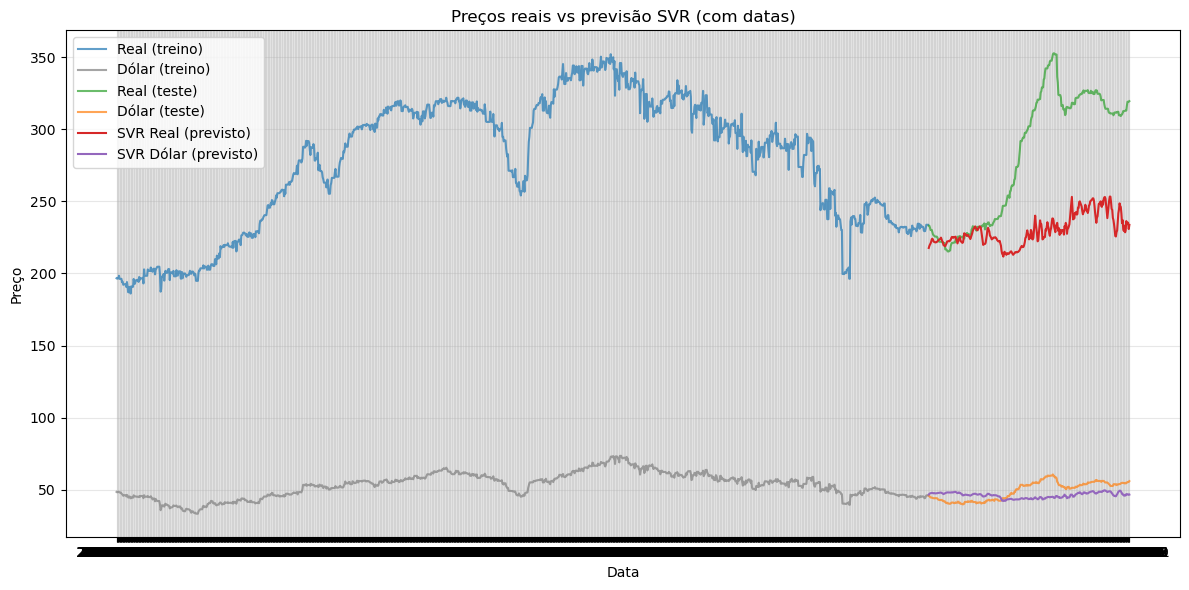

In [165]:
plt.figure(figsize=(12, 6))

#plt.plot(last_window_dates, X_test_rescaled, label='Última janela X_test', color='tab:orange', linestyle='--')
plt.plot(y_dates_train, y_train_rescaled[:, 0], label='Real (treino)', color='tab:blue', alpha=0.7)
plt.plot(y_dates_train, y_train_rescaled[:, 1], label='Dólar (treino)', color='tab:gray', alpha=0.7)

plt.plot(y_dates_test,  y_test_rescaled[:, 0],  label='Real (teste)', color='tab:green', alpha=0.7)
plt.plot(y_dates_test,  y_test_rescaled[:, 1],  label='Dólar (teste)', color='tab:orange', alpha=0.7)

plt.plot(y_dates_test,  y_pred_rescaled[:, 0],  label='SVR Real (previsto)', color='tab:red')
plt.plot(y_dates_test,  y_pred_rescaled[:, 1],  label='SVR Dólar (previsto)', color='tab:purple')

plt.title('Preços reais vs previsão SVR (com datas)')
plt.xlabel('Data')
plt.ylabel('Preço')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## PCA

In [253]:
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import Pipeline

In [246]:
df_sel = pd.read_csv('df_normalized.csv', index_col='data')
df_sel.head()

,CovidPeriodFlag,ano_novo_flag,carnaval_core_flag,carnaval_window_flag,pascoa_flag,pascoa_window_flag,dias_maes_flag,dias_maes_weekend_flag,festas_juninas_flag,santo_antonio_flag,...,milho_Vol.,milho_real,milho_dolar,taxa,ciclo_MENOR_TX_NASC,ciclo_NASC_COMPLEMENTARES,ciclo_PICO_NASCIMENTOS,aspecto_PLANEJAMENTO,aspecto_SAFRA,el_nino_encoded
data,,,,,,,,,,,,,,,,,,,,,
2020-01-02,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.406033,0.575179,0.641516,0.000000,0,0,1,1,0,0.5
2020-01-03,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.455546,0.575179,0.641516,0.011745,0,0,1,1,0,0.5
2020-01-04,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.455546,0.540149,0.628997,0.011745,0,0,1,1,0,0.5
2020-01-05,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.455546,0.540149,0.628997,0.011745,0,0,1,1,0,0.5
2020-01-06,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.424853,0.545706,0.612785,0.010212,0,0,1,1,0,0.5


In [247]:
# Criar lags
n_lags = 3
for col in df_sel.columns:
    for i in range(1, n_lags + 1):
        df_sel[f'{col}_lag_{i}'] = df_sel[col].shift(i)
df_sel.dropna(inplace=True)

In [248]:
x_cols = ['CovidPeriodFlag',
        'ano_novo_flag',
        'carnaval_core_flag',
        'carnaval_window_flag',
        'pascoa_flag',
        'pascoa_window_flag',
        'dias_maes_flag',
        'dias_maes_weekend_flag',
        'festas_juninas_flag',
        'santo_antonio_flag',
        'sao_joao_flag',
        'sao_pedro_flag',
        'ferias_midyear_flag',
        'ferias_verao_flag',
        'dias_pais_flag',
        'dias_pais_weekend_flag',
        'independencia_flag',
        'independencia_window_flag',
        'dia_criancas_flag',
        'finados_flag',
        'finados_weekend_flag',
        'natal_flag',
        'natal_window_flag',
        'fim_ano_window_flag',
        'sazonal_carne_weight',
        'scpdsi_goias',
        'precip_total_mm',
        'TEMPERATURA',
        'ipca',
        'selic',
        'PIB',
        'PIB_Agro',
        'cme_valor',
        'cme_Vol.',
        'boi_futuro',
        'boi_futuro_Vol.',
        'soja_real',
        'soja_dolar',
        'soja_futuro',
        'soja_Vol.',
        'milho_futuro',
        'milho_Vol.',
        'milho_real',
        'milho_dolar',
        'taxa',
        'ciclo_MENOR_TX_NASC',
        'ciclo_NASC_COMPLEMENTARES',
        'ciclo_PICO_NASCIMENTOS',
        'aspecto_PLANEJAMENTO',
        'aspecto_SAFRA',
        'el_nino_encoded']

In [262]:
X = df_sel[[f'{col}_lag_{i}' for col in x_cols for i in range(1, n_lags + 1)]].values
X

array([[0. , 0. , 0. , ..., 0.5, 0.5, 0.5],
       [0. , 0. , 0. , ..., 0.5, 0.5, 0.5],
       [0. , 0. , 0. , ..., 0.5, 0.5, 0.5],
       ...,
       [0. , 0. , 0. , ..., 0.5, 0.5, 0.5],
       [0. , 0. , 0. , ..., 0.5, 0.5, 0.5],
       [0. , 0. , 0. , ..., 0.5, 0.5, 0.5]], shape=(1657, 153))

In [264]:
y = df_sel[['boi_real', 'boi_dolar']].values
y

array([[196.7 ,  48.53],
       [196.4 ,  48.24],
       [196.6 ,  48.42],
       ...,
       [319.1 ,  55.42],
       [319.1 ,  55.42],
       [319.5 ,  55.99]], shape=(1657, 2))

In [265]:
# Split temporal
train_size = int(len(df_sel) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]


In [266]:
def build_pipeline(trial):
    # Número de componentes PCA
    n_components = trial.suggest_int('n_components', 2, X.shape[1])  # entre 2 e total de features

    # Hiperparâmetros SVR

    C = trial.suggest_float('C', 1e-2, 1e3, log=True)
    gamma = trial.suggest_float('gamma', 1e-4, 10.0, log=True)
    epsilon = trial.suggest_float('epsilon', 1e-3, 0.5, log=True)
    kernel = trial.suggest_categorical('kernel', ['rbf', 'poly', 'linear'])
    degree = trial.suggest_int('degree', 2, 5) if kernel == 'poly' else 3

    svr = SVR(kernel=kernel, C=C, gamma=gamma, epsilon=epsilon, degree=degree)

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=n_components)),
        ('svr', svr)
    ])
    return pipeline

In [267]:
# 3. Objetivo do Optuna com TimeSeriesSplit
def objective(trial):
    pipelines = [build_pipeline(trial) for _ in range(y_train.shape[1])]
    tscv = TimeSeriesSplit(n_splits=5)

    scores = []

    for i in range(y_train.shape[1]):
        fold_scores = []
        for train_idx, val_idx in tscv.split(X_train):
            X_tr, X_val = X_train[train_idx], X_train[val_idx]
            y_tr, y_val = y_train[train_idx, i], y_train[val_idx, i]
            pipelines[i].fit(X_tr, y_tr)
            y_pred = pipelines[i].predict(X_val)
            fold_scores.append(r2_score(y_val, y_pred))
        scores.append(np.mean(fold_scores))

    return np.mean(scores)



In [ ]:
# Rodar estudo
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=60)

In [270]:
print("Melhores parâmetros:", study.best_params)
print("Melhor R² médio (CV):", study.best_value)



Melhores parâmetros: {'n_components': 153, 'C': 54.45625657676487, 'gamma': 0.09404513998449253, 'epsilon': 0.15204438169984208, 'kernel': 'rbf'}
Melhor R² médio (CV): -6.193828687018996


In [271]:
# 5. Treinar pipelines finais para cada saída
best_pipelines = [build_pipeline(study.best_trial) for _ in range(y_train.shape[1])]
for i in range(y_train.shape[1]):
    best_pipelines[i].fit(X_train, y_train[:, i])


In [272]:
# 6. Previsões
y_pred = np.column_stack([best_pipelines[i].predict(X_test) for i in range(y_train.shape[1])])


In [276]:
# Avaliação por saída
for i, col in enumerate(['boi_real', 'boi_dolar']):
    r2 = r2_score(y_test[:, i], y_pred[:, i])
    rmse = root_mean_squared_error(y_test[:, i], y_pred[:, i])
    print(f"{col}: R²={r2:.4f} | RMSE={rmse:.4f}")


boi_real: R²=0.0251 | RMSE=44.1924
boi_dolar: R²=-0.4177 | RMSE=7.4317


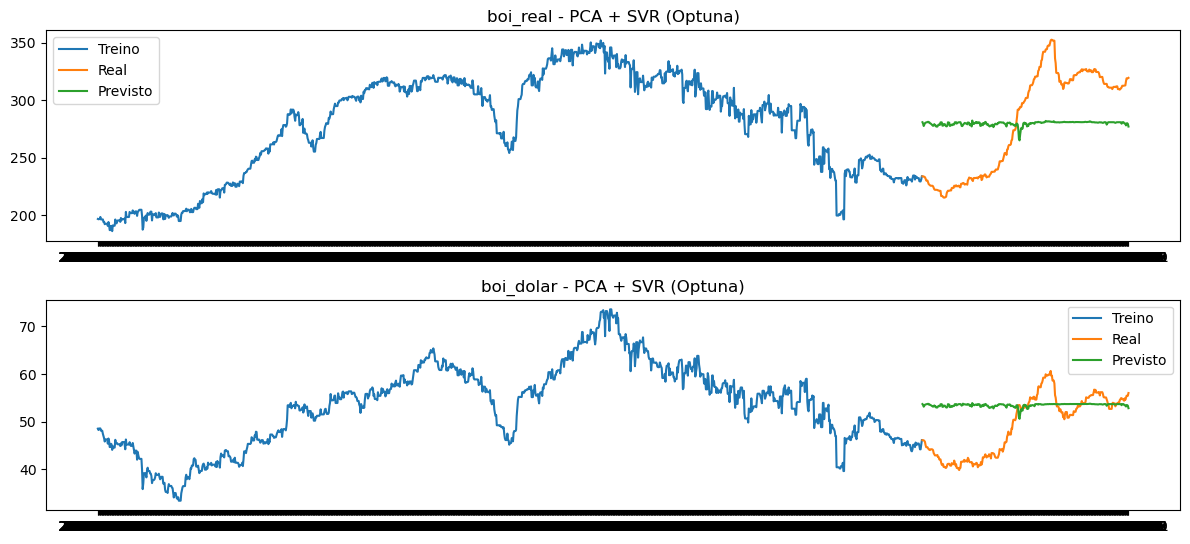

In [287]:
# 7. Visualização
plt.figure(figsize=(12, 8))
for i, col in enumerate(['boi_real', 'boi_dolar']):
    plt.subplot(3, 1, i+1)
    plt.plot(df_sel.index[:train_size], y_train[:, i], label='Treino')
    plt.plot(df_sel.index[train_size:], y_test[:, i], label='Real')
    plt.plot(df_sel.index[train_size:], y_pred[:, i], label='Previsto')
    plt.title(f'{col} - PCA + SVR (Optuna)')
    plt.legend()
plt.tight_layout()
plt.show()
